[0.000000e+00 3.906250e-04 7.812500e-04 ... 9.984375e-01 1.000000e+00
 1.000000e+00]
[ 1.          0.99648232  0.9929619  ... -3.1402215  -3.14043712
 -3.14043712]


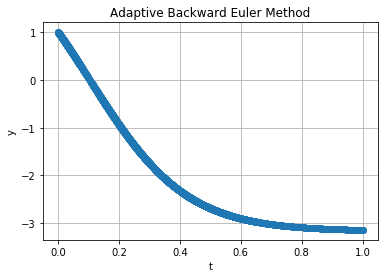

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define dy/dt = f(t, y)
def f(t, y):
    return y**2 - 10

# Derivative of f with respect to y
def fprime(y):
    return 2*y


# Newton-Raphson for one Backward Euler step
def backward_euler_step(f, y, t, h, tol=1e-6, max_iter=50):
    y_next = y  # initial guess

    for _ in range(max_iter):
        g_val = y_next - y - h * f(t + h, y_next)
        g_prime_val = 1 - h * fprime(y_next)

        if abs(g_prime_val) < tol:
            break

        y_new = y_next - g_val / g_prime_val

        if abs(y_new - y_next) < tol:
            return y_new

        y_next = y_new

    return y_next


# Adaptive Backward Euler method
def backward_euler_adaptive(f, y0, t0, tf, h_init, tol=1e-6, max_iter=50):
    t_values = [t0]
    y_values = [y0]

    h = h_init
    t = t0
    y = y0

    while t < tf:
        if t + h > tf:
            h = tf - t

        # One full step
        y_full = backward_euler_step(f, y, t, h, tol, max_iter)

        # Two half steps
        h_half = h / 2
        y_half_1 = backward_euler_step(f, y, t, h_half, tol, max_iter)
        y_half_2 = backward_euler_step(f, y_half_1, t + h_half, h_half, tol, max_iter)

        # Estimate error
        error = abs(y_full - y_half_2)

        # Reject step if error is too large
        if error > tol:
            h /= 2
            continue

        # Accept step
        t += h
        y = y_half_2

        t_values.append(t)
        y_values.append(y)

        # Increase step size if error is very small
        if error < tol / 2:
            h *= 2

    return np.array(t_values), np.array(y_values)


# Example run
y0 = 1
t0 = 0
tf = 1
h_init = 0.1
tol = 1e-6

t_values, y_values = backward_euler_adaptive(f, y0, t0, tf, h_init, tol)

print(t_values)
print(y_values)

plt.plot(t_values, y_values, marker="o")
plt.xlabel("t")
plt.ylabel("y")
plt.title("Adaptive Backward Euler Method")
plt.grid(True)
plt.show()